# Initial Bauwerk Decision-Transformer Experiments
In this notebook, we'll lay out initial experiments to validate the Decision Transformer architecture in a controlled setting. We'll run three experiments:
1. **Overfit DT**: DT trained and evaluated on one task. 
2. **Underfit DT**: DT trained on one task and evaluated on others.
3. **General DT**: DT trained and evaluated on all tasks.

We compose the training sets of optimal state-action trajectories from the relevant task. In the future, we will relax this constraint and use trajectories collected by ~optimal specialist RL agents trained in the relevant task. Before we proceed to more complicated building simulations, DT must perform competently on tests 1 and 3 (task 2 will be used to understand how well DT can generalise across tasks, and we do not expect strong performance). As with previous experiments, we'll measure performance $p^{'}$ of our controller $p_{dt}$ relative to a random controller $p_{r}$ and an optimal controller $p_{o}$ via the following relationship

$$
p^{'} = \frac{p_{dt} - p_{r}}{p_{o} - p_{r}}
$$

To complete a test, we'll require the performance $p^{'}$ of the method under evaluation to be $>0.9$. First we'll import the required packages, then set up experiment 1.

In [2]:
import gym
import bauwerk
import bauwerk.benchmarks

import torch
import numpy as np
from tqdm import tqdm

from utils.utils import Cfg
from utils.utils import ObsWrapper
from agent.DT.agent import Agent
from data.tokenizer import Tokenizer

# load config
Cfg = Cfg()
cfg = Cfg.parse(model='dt')

# import tokenizer
tokenizer = Tokenizer(cfg.tokenizer)

# instantiate one agent per experiment
model1 = Agent(cfg)
model2 = Agent(cfg)
model3 = Agent(cfg)

task0_model_path = 'agent/DT/saved_models/task0_month.pth'
alltasks_model_path = 'agent/DT/saved_models/all_tasks.pth'

/Users/scottjeen/miniforge3/envs/odes/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We'll set up a helper function to calculate the performance of a rollout of actions of abitrary length, this will be useful for evaluating optimal and random actions.

In [3]:
def evaluate_actions(actions, env, prompt_steps):
    cum_reward = 0
    obs = env.reset()
    obses = []
    for i, action in enumerate(actions):
        obs, reward, done, info = env.step(np.array(action, dtype=np.float32))
        obses.append(obs)
        # if i >= prompt_steps:
        cum_reward += reward

    return cum_reward / len(actions) 

We need a function that creates a `prompt` for the agent. The `prompt` is a sequence of tokens to use as the agent's first input; in the Gato paper, the authors suggest the prompt primes the network for the task it is about to perform. In this case, we'll build the `prompt` using the first few optimal actions in the environment. We take as many actions as are required to create a prompt with length equal to the sequences used to pre-train the agent -- in our case that's 64 tokens.

In [4]:
def prompt(env, obs_dim, act_dim, prompt_steps):
    """
    Creates task-specifc tokenized prompt for DT.
    :param env: Bauwerk environment set to relevant task
    :param cfg: (dict) decision transformer config.
    :return tokenized prompt: array of state-action tokens, shape [context_length,]
    """
    print('...creating prompt...')
    optimal_actions = bauwerk.solve(env)[0]
    state_actions = []
    
    # create masks
    obs_mask = np.zeros(shape=(prompt_steps + 1, obs_dim + act_dim))  # +1 because we include final additional obs
    act_mask = np.zeros(shape=(prompt_steps, obs_dim + act_dim))
    obs_mask[:, :obs_dim] = np.arange(start=1, stop=obs_dim+1)
    act_mask[:, obs_dim: obs_dim + act_dim] = 1
    obs_mask = obs_mask.flatten()[-cfg.transformer.context_length:]
    act_mask = act_mask.flatten()[-cfg.transformer.context_length:]
    
    obs = env.reset()
    for step in range(prompt_steps):
        state_actions.append(obs)
        action = optimal_actions[step]
        obs, _, _, _ = env.step(action)
        state_actions.append(action)
    
    state_actions.append(obs)
    
    # correct masks for last obs
    obs_mask[:-obs_dim] = obs_mask[obs_dim:]
    obs_mask[-obs_dim:] = np.arange(start=1, stop=obs_dim+1)
    act_mask[:-obs_dim] = act_mask[obs_dim:]
    act_mask[-obs_dim:] = 0
    
    prompt = np.concatenate(np.array(state_actions, dtype=object))[-cfg.transformer.context_length:]  # flattened array sliced to context length 
    tokenised_prompt = tokenizer.tokenize(prompt) 
        
    return tokenised_prompt, obs_mask, act_mask

Now we'll create a function that sets up a task and performs an evalutive rollout with our agent. We need this function to step the simulator until the end of the prompt sequence, after which the agent can take control.

In [4]:
def rollout_with_prompt(model, env, eval_steps):
    act_dim = int(env.action_space.shape[0])
    obs_dim = 5
    model_actions = []
    optimal_actions = bauwerk.solve(env)[0]
    rollout_reward = 0
    prompt_steps = int(np.ceil(cfg.transformer.context_length / (obs_dim + act_dim)))  # +1 for 1-d action

    ### we have to create two ugly loops to give DT the env after prompt steps ###
    
    # loop 1: setting up env
    print('...preparing env...')
    obs = env.reset()
    for i in range(prompt_steps):
        action = optimal_actions[i]
        obs, _, _, _ = env.step(action)

    # create prompt sequence
    tokens, obs_mask, act_mask = prompt(env, obs_dim, act_dim, prompt_steps)
    
    # loop 2: eval rollout
    print('...collecting rollout...')
    for _ in tqdm(range(eval_steps)):
        action_dims = []
        # we predict action dimensions one-by-one
        for _ in range(act_dim):
            out_seq = model.predict_sequence(
                input_sequence=np.expand_dims(tokens, axis=0),
                obs_mask=np.expand_dims(obs_mask, axis=0),
                act_mask=np.expand_dims(act_mask, axis=0)
            )
            action_dims.append(out_seq[:, -1].detach().numpy())  # action dim is final dim of predicted sequence
            act_token = tokenizer.tokenize(action_dims[-1])
            tokens, obs_mask, act_mask = tokenizer.update_sequences(tokens, obs_mask, act_mask, act_token, action=True)
        
        action = np.array(action_dims, dtype=np.float32).flatten()
        obs, reward, _, _ = env.step(action)
        
        
        obs_tokens = tokenizer.tokenize(obs)
        tokens, obs_mask, act_mask = tokenizer.update_sequences(tokens, obs_mask, act_mask, obs_tokens, obs=True)        
        model_actions.append(action)
        rollout_reward += reward
        
    mean_reward = rollout_reward / len(model_actions)

    return mean_reward, model_actions

## Experiment 1: Overfit DT
Here, we'll import DT parameters fit to Bauwerk's $0^{th}$ Task. We'll evaluate DT on the same Task.


In [17]:
# import pre-trained model
model1.load_state_dict(torch.load(task0_model_path))
model1.eval()

# setup env                   
build_dist_b = bauwerk.benchmarks.BuildDistB(seed=0)
env = build_dist_b.make_env()
env = ObsWrapper(env)
env.set_task(build_dist_b.train_tasks[0])
obs_dim = 5
act_dim = 1

# DT rollout
prompt_steps = int(np.ceil(cfg.transformer.context_length / (obs_dim + act_dim)))  # +1 for 1-d action
dt_reward, model_actions = rollout_with_prompt(model=model1, env=env, eval_steps=int(24 * 30))

# optimal rollout
optimal_actions = bauwerk.solve(env)
optimal_reward = evaluate_actions(optimal_actions[0][:24*30 + prompt_steps], env, prompt_steps)

# random rollout
random_actions = [env.action_space.sample() for _ in range(24 * 30)]
random_reward = evaluate_actions(random_actions[:24*30 + prompt_steps], env, prompt_steps)

# no charging
nocharge_reward = evaluate_actions(np.zeros((24*30 + prompt_steps,1)), env, prompt_steps)

# performance
dt_p = (dt_reward - random_reward) / (optimal_reward - random_reward)
nc_p = (nocharge_reward - random_reward) / (optimal_reward - random_reward)

print('mean grid payment (optimal actions): {:.3f}'.format(optimal_reward))
print('mean grid payment (random actions): {:.3f}'.format(random_reward))
print('mean grid payment (no charge): {:.3f}'.format(nocharge_reward))
print('mean grid payment (dt actions): {:.3f}'.format(dt_reward))
print('\n')
print('DT Performance: {:.3f}'.format(dt_p))
print('No-charge Performance: {:.3f}'.format(nc_p))

...preparing env...
...creating prompt...


/Users/scottjeen/phd/research/elizabeth-homes/exp/enjeeneer/rl-exp2/data/tokenizer.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


...collecting rollout...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:09<00:00, 78.22it/s]


mean grid payment (optimal actions): -0.104
mean grid payment (random actions): -0.673
mean grid payment (no charge): -0.156
mean grid payment (dt actions): -0.155


DT Performance: 0.910
No-charge Performance: 0.908


We find that DT beats the `no_charge` performance, and passes of $0.9$ task threshold. It does not, however, perfectly imitate optimality. 

## Experiment 2: Underfit DT
Here, we'll use the same model as the last experiment -- i.e. DT with parameters fit to Bauwerk's $0^{th}$ Task -- but this time evaluate on all Bauwerk tasks with 20 battery sizes in the range `[1,20]`.

In [5]:
# setup                 
build_dist_b = bauwerk.benchmarks.BuildDistB(seed=0)
tasks = build_dist_b.train_tasks
obs_dim = 5
act_dim = 1
prompt_steps = int(np.ceil(cfg.transformer.context_length / (obs_dim + act_dim)))  # +1 for 1-d action

# logging
optimal_rewards = []
random_rewards = []
no_charge_rewards = []
dt_rewards = []
eval_steps = int(24 * 30)

battery_sizes = np.arange(1,21,1)
for size in battery_sizes:
    # set task
    env = build_dist_b.make_env()
    task = bauwerk.benchmarks.Task(
                    env_name=str(size),
        cfg=bauwerk.envs.solar_battery_house.EnvConfig(
            battery_size=size,
        )
    )
    env.set_task(task)
    env = ObsWrapper(env)
    
    # DT rollout
    # dt_reward, model_actions = rollout_with_prompt(model=model1, env=env, eval_steps=int(24 * 30))
    # dt_rewards.append(dt_reward)

    # optimal rollout
    optimal_actions = bauwerk.solve(env)
    optimal_reward = evaluate_actions(optimal_actions[0][:eval_steps], env, prompt_steps)
    optimal_rewards.append(optimal_reward)

    # random rollout
    # random_actions = [env.action_space.sample() for _ in range(24 * 30)]
    # random_reward = evaluate_actions(random_actions[:24*30 + prompt_steps], env, prompt_steps)
    # random_rewards.append(random_reward)
    #
    # # no charging
    # nocharge_reward = evaluate_actions(np.zeros((24*30 + prompt_steps,1)), env, prompt_steps)
    # no_charge_rewards.append(nocharge_reward)
    #
    # # performance
    # dt_p = (dt_reward - random_reward) / (optimal_reward - random_reward)
    
    # # print
    # print('Battery size: {:d}kWh | DT Performance: {:.3f}'.format(size, dt_p))

bauwerk: Setting task with differing episode_len (8759) from prior episode_len set in env (720). This may lead to unexpected behaviour.
bauwerk: Setting task with differing episode_len (8759) from prior episode_len set in env (720). This may lead to unexpected behaviour.
bauwerk: Setting task with differing episode_len (8759) from prior episode_len set in env (720). This may lead to unexpected behaviour.
bauwerk: Setting task with differing episode_len (8759) from prior episode_len set in env (720). This may lead to unexpected behaviour.
bauwerk: Setting task with differing episode_len (8759) from prior episode_len set in env (720). This may lead to unexpected behaviour.
bauwerk: Setting task with differing episode_len (8759) from prior episode_len set in env (720). This may lead to unexpected behaviour.
bauwerk: Setting task with differing episode_len (8759) from prior episode_len set in env (720). This may lead to unexpected behaviour.
bauwerk: Setting task with differing episode_len

Now we'll plot the results:

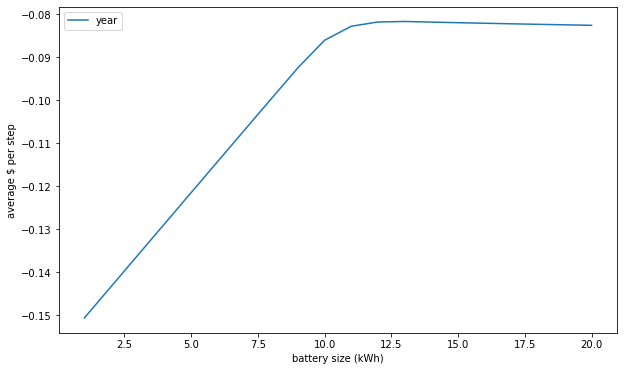

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1, figsize=(10,6))
plt.plot(np.arange(1,21,1), optimal_rewards, label='year')
# plt.plot(np.arange(1,21,1), dt_rewarads, label='DT')
# plt.plot(np.arange(1,21,1), random_rewards, label='random')
# plt.plot(np.arange(1,21,1), no_charge_rewards, label='no charging', linestyle='--', color='lightblue')
plt.ylabel('average $ per step')
plt.xlabel('battery size (kWh)')
plt.legend()
           

We see that the underfit model performs better than the `no_charge` policy for most battery sizes, but fails to match the optimal policy for all but one battery size.

## Experiment 3: General DT
Fianlly, we'll use a third model that has been trained on optimal data from the train tasks and evaluate on all Bauwerk tasks with 20 battery sizes in the range `[1,20]`.

In [74]:
# call general dt model params
model3.load_state_dict(torch.load(alltasks_model_path))
model3.eval()

# setup                 
build_dist_b = bauwerk.benchmarks.BuildDistB(seed=0)
tasks = build_dist_b.train_tasks
obs_dim = 5
act_dim = 1
prompt_steps = int(np.ceil(cfg.transformer.context_length / (obs_dim + act_dim)))  # +1 for 1-d action

# logging
optimal_rewards = []
random_rewards = []
no_charge_rewards = []
dt_rewards = []

battery_sizes = np.arange(1,21,1)
for size in battery_sizes:
    # set task
    env = build_dist_b.make_env()
    task = bauwerk.benchmarks.Task(
                    env_name=str(size),
        cfg=bauwerk.envs.solar_battery_house.EnvConfig(
            battery_size=size,
            episode_len=24*30+prompt_steps,
        )
    )
    env.set_task(task)
    env = ObsWrapper(env)
    
    # DT rollout
    dt_reward, model_actions = rollout_with_prompt(model=model3, env=env, eval_steps=int(24 * 30))
    dt_rewards.append(dt_reward)

    # optimal rollout
    optimal_actions = bauwerk.solve(env)
    optimal_reward = evaluate_actions(optimal_actions[0][:24*30 + prompt_steps], env, prompt_steps)
    optimal_rewards.append(optimal_reward)

    # random rollout
    random_actions = [env.action_space.sample() for _ in range(24 * 30)]
    random_reward = evaluate_actions(random_actions[:24*30 + prompt_steps], env, prompt_steps)
    random_rewards.append(random_reward)
    
    # no charging
    nocharge_reward = evaluate_actions(np.zeros((24*30 + prompt_steps,1)), env, prompt_steps)
    no_charge_rewards.append(nocharge_reward)

    # performance
    dt_p = (dt_reward - random_reward) / (optimal_reward - random_reward)    
    
    # print
    print('Battery size: {:d}kWh | DT Performance: {:.3f}'.format(size, dt_p))

...preparing env...
...creating prompt...
...collecting rollout...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:11<00:00, 64.12it/s]


Battery size: 1kWh | DT Performance: 0.452
...preparing env...
...creating prompt...
...collecting rollout...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:11<00:00, 64.71it/s]


Battery size: 2kWh | DT Performance: 0.772
...preparing env...
...creating prompt...
...collecting rollout...


...

Battery size: 18kWh | DT Performance: 0.931
...preparing env...
...creating prompt...
...collecting rollout...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:11<00:00, 64.77it/s]


Battery size: 19kWh | DT Performance: 0.927
...preparing env...
...creating prompt...
...collecting rollout...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:11<00:00, 64.06it/s]


Battery size: 20kWh | DT Performance: 0.934


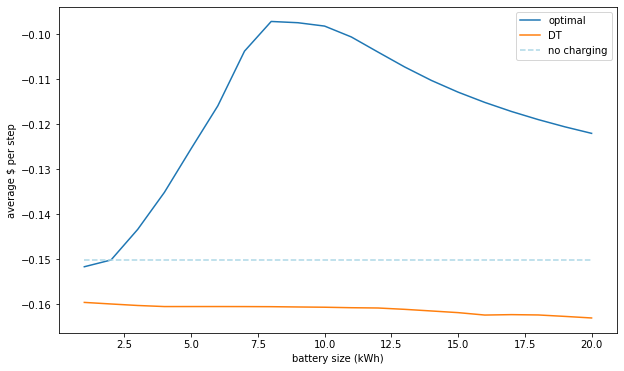

In [75]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1, figsize=(10,6))
plt.plot(np.arange(1,21,1), optimal_rewards, label='optimal')
plt.plot(np.arange(1,21,1), dt_rewards, label='DT')
# plt.plot(np.arange(1,21,1), random_rewards, label='random')
plt.plot(np.arange(1,21,1), no_charge_rewards, label='no charging', linestyle='--', color='lightblue')
plt.ylabel('average $ per step')
plt.xlabel('battery size (kWh)')
plt.legend()

We find that the model trained on a more general dataset (1 year of data for each Bauwerk task) is less performative than the `underfit` model. Some hypothesises for why this may be the case:
- The underfit model is trained solely on transitions from the evaluation period, albeit from one task instead of many. It's possible that this focuses the model to only care about extrinsic data from that month which generalises quite well across tasks.
- Training on optimal actions means the model will struggle when it (inevitably) vears from optimality. Training on data $>= 0.8 \times optimal$ should help here.
- The Bauwerk `train tasks` are not spread across the battery range `[1,20]` and are instead roughly in the range `[5,11]`. In a sense this means we overfit to battery sizes in the middle of the test distribution, though admittedly we do not see better performance on those battery sizes.

## Next Steps
Our goal is to find an agent that generalises better than the undefit model from experiment 2. We can look to achieve this by:
- Implementing SOTA baselines and comparing performance.
- Maximising performance on experiment 1 via hyperparamter tuning.
- Investigating training on sub-optimal data.
- Training on the battery sizes seen in the test set.
- Augmenting state-space with task-specific features.

## Next-Next Steps
- Build online finetuning mechanism and test
- Test on more complex environments